In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df=pd.read_csv(r"C:\Users\Waheed Bepari\OneDrive\Desktop\DATA SCIENCE COURSE\DEEP LEARNING + AI\sales_data.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
df.shape

(76000, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [5]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [6]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df = df.sort_values('Date')

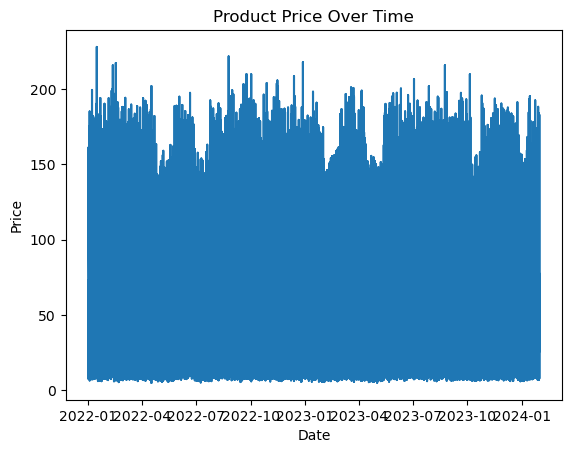

In [10]:
plt.plot(df['Date'], df['Price'])

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Product Price Over Time')

plt.show()

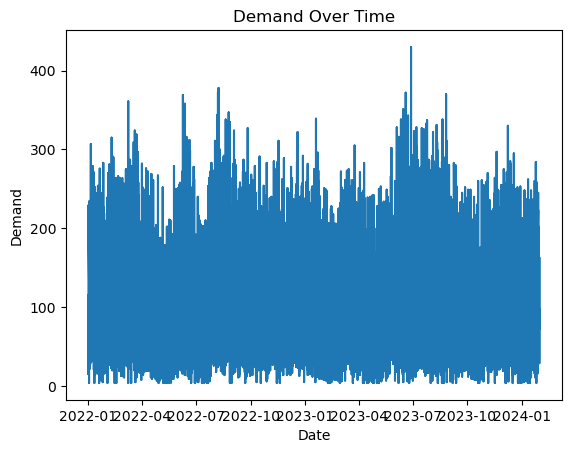

In [11]:
plt.plot(df['Date'], df['Demand'])

plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('Demand Over Time')

plt.show()

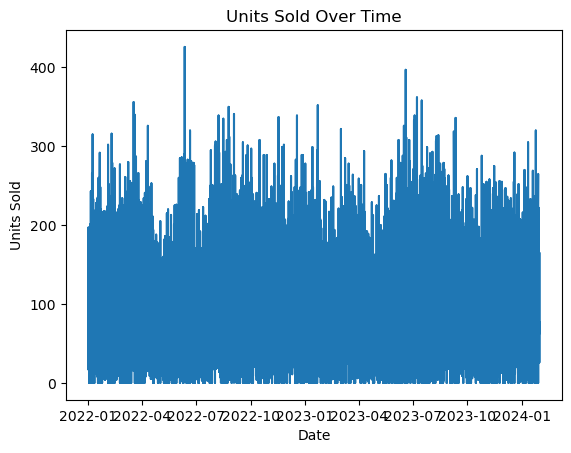

In [13]:
plt.plot(df['Date'], df['Units Sold'])

plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.title('Units Sold Over Time')

plt.show()

In [18]:
features = [
    'Price',
    'Demand',
    'Units Sold',
    'Competitor Pricing',
    'Inventory Level',
    'Discount'
]

In [19]:
data = df[features]

In [20]:
data.head()

,Price,Demand,Units Sold,Competitor Pricing,Inventory Level,Discount
0,72.72,115,102,85.73,195,5
72,20.24,110,104,18.90,136,10
71,118.15,103,111,133.46,111,0
70,52.89,61,60,62.29,195,0
69,30.02,128,120,29.15,223,0


In [21]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [41]:
sequence_length = 14

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    
    X.append(
        scaled_data[i-sequence_length:i]
    )
    
    y.append(
        scaled_data[i, 0]
    )

In [42]:
X = np.array(X)
y = np.array(y)

In [43]:
X.shape

(75986, 14, 6)

In [44]:
y.shape

(75986,)

In [45]:
split = int(len(X) * 0.80)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [46]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(60788, 14, 6)
(15198, 14, 6)
(60788,)
(15198,)


In [71]:
model = Sequential([
    
    LSTM(
        64,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    
    Dense(
        32,
        activation='relu'
    ),
    
    Dense(1)
])

C:\Users\Waheed Bepari\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [73]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [75]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0286 - mae: 0.1386 - val_loss: 0.0285 - val_mae: 0.1361
Epoch 2/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0228 - mae: 0.1202 - val_loss: 0.0202 - val_mae: 0.1117
Epoch 3/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0190 - mae: 0.1068 - val_loss: 0.0169 - val_mae: 0.1003
Epoch 4/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0161 - mae: 0.0972 - val_loss: 0.0140 - val_mae: 0.0910
Epoch 5/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0137 - mae: 0.0880 - val_loss: 0.0124 - val_mae: 0.0833
Epoch 6/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0118 - mae: 0.0805 - val_loss: 0.0099 - val_mae: 0.0732
Epoch 7/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0103 - mae: 0.0745 - val_loss: 0.0089 - val_mae: 0.0687
Epoch 8/40
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0092 - mae: 0.0699 - val_loss: 0.0082 - val_mae: 0.0666
Epoch 9/40
1520/1520 ━━━

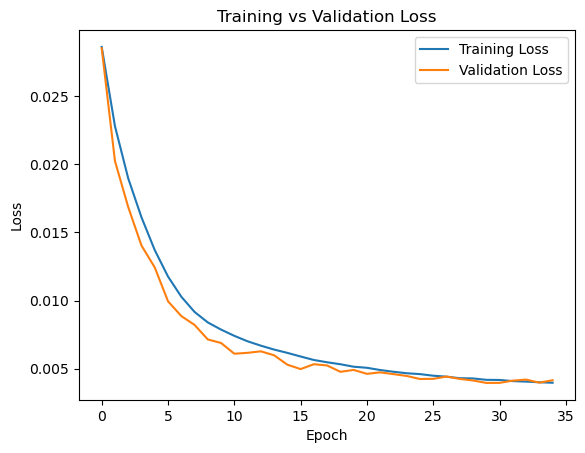

In [76]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [77]:
y_pred = model.predict(X_test)

475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [78]:
y_pred[:5]

array([[0.40643784],
       [0.08425203],
       [0.09442142],
       [0.24265227],
       [0.46330202]], dtype=float32)

In [79]:
price_scaler = MinMaxScaler()

price_scaler.fit(
    df[['Price']]
)

y_pred_actual = price_scaler.inverse_transform(y_pred)

y_test_actual = price_scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

In [80]:
mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

In [81]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 11.172377376604185
RMSE: 16.143568582680913
R2 Score: 0.8307249830357231


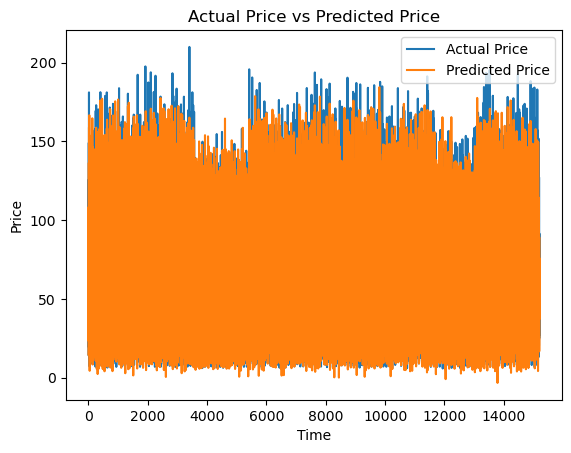

In [82]:
plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    y_pred_actual,
    label='Predicted Price'
)

plt.xlabel('Time')
plt.ylabel('Price')

plt.title(
    'Actual Price vs Predicted Price'
)

plt.legend()

plt.show()